In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sym
import sympy.plotting.plot as symplot

2*x**2
4*x


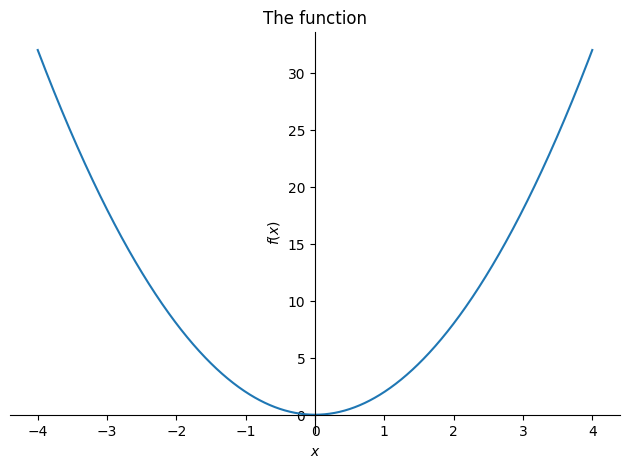

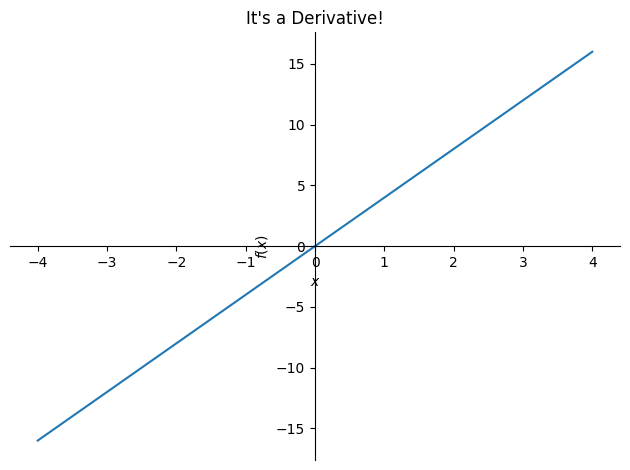

In [3]:
x = sym.symbols('x')
fx = 2*x**2
df = sym.diff(fx,x)
print(fx)
print(df)

symplot(fx,(x,-4,4),title='The function')
plt.show()
symplot(df,(x,-4,4),title = "It's a Derivative!")
plt.show()


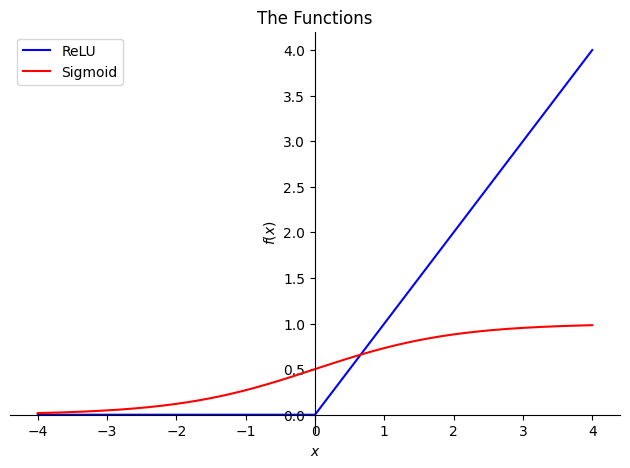

In [4]:
# repeat with relu and sigmoid
relu = sym.Max(0,x)
sigmoid = 1 / (1+sym.exp(-x))

# graph 

p = symplot(relu,(x,-4,4),label="ReLU", show=False,line_color='blue')
p.extend(symplot(sigmoid,(x,-4,4),label='Sigmoid',show=False,line_color='red'))
p.legend = True
p.title = 'The Functions'
p.show()


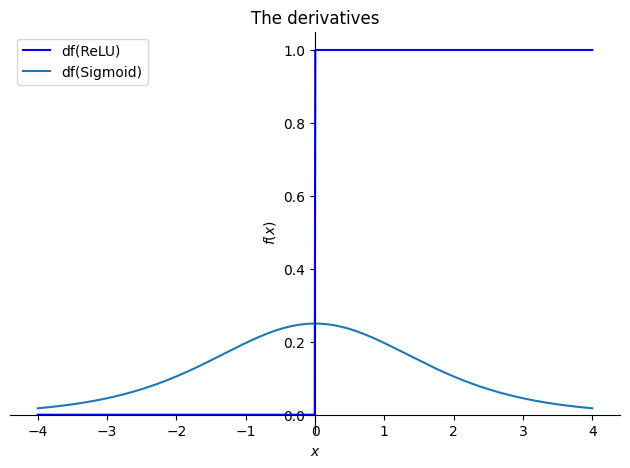

In [5]:
# graph their derivatives
p = symplot(sym.diff(relu),(x,-4,4),label='df(ReLU)',show=False,line_color='blue')
p.extend( symplot(sym.diff(sigmoid),(x,-4,4),label='df(Sigmoid)',show=False,lne_color='red'))
p.legend=True
p.title = "The derivatives"
p.show()

Finding local minima
- The main purpose of derivatives in gradient descent
- What "minima" and "maxima" are
- How to distinguish local minima and local maxima

It turns out the derivative can tell us where the minima and maxima are. Where the fcn has a derivative of zero, that's where the minima and maxima are.
We start with a function: 
<font color="yellow" size="10px">

$f(x) = -x^{4} + 3x^{2}$
</font>
<font color="orange" size="10px">

$\frac{df}{dx} = -4x^{3} + 6x$
</font>
So we have a 3rd order polynomial so we'll have 3 solutions: 

$-4x^{3} + 6x = 0$

Now the exact answers don't really matter here, the point is that we identify the minima and maxima of the function by computing the derivative, setting the derivative to zero, and then solving for x.
That gives us the minimum and the maximum. Now these points here, these are called the critical points. They don't actually tell us which one is a minimum and which is a maximum, these just tell us that these are the points
where the derivative is zero.

![alt text](img/minima-maxima-diag1.png)

The minima and maxima have a derivative, this is df, the derivative of the function equals zero. When we look at the minima, the minima have a negative derivative to the left and a positive derivative to the right, so we can see that in this example. We have our derivative equals zero, when we look to the left the derivative is negative and when we look to the right the derivative is positive,so that means that this is a minimum point. Conversely, when we look at the maxima we have exactly the opposite situation,
so the derivative is positive to the left and negative to the right.

<font color="orange">Minima: df < 0 to left, df > 0 to the right </font>

<font color="yellow">Maxima: df > 0 to left, df < 0 to the right </font>

<font color="darkorange">Constant: "Vanishing gradient" </font>



You might have gotten the sense that computing derivatives is really easy and really straightforward.
Well, that kind of is the case for relatively simple functions like polynomials and sine and cosine.

However, when we start getting to more complicated functions, and in particular multiplied functions or embedded functions, things are not so simple anymore, and computing the derivatives of more complicated functions becomes more complicated.

<font color="teal" size="8px">Product Rule and Chain Rule</font>

<font color="orange">The "product rule" of derivatives of multiple functions.</font>

<font color="yellow">The "chain rule" of derivatives of embedded functions</font>

What to remember from this lecture?
- Derivatives of "interacting" functions (multiplication and embedding) is unintuitive.
- Simple functions are more intuitve IMU
- In practice, librarie like pytorch,tensorflow, etc. have routines that estimate complicated derivatives very efficiently and accurately.

<font color="teal" size="11px">Product Rule</font>
<font color="green">

$(f + g)^{\prime}$ = $f^{\prime} + g^{\prime}$

</font>
Now adding two diveratives like we did above might seem straightforward but in multplication, that doesn't work!
<font color="red">

$(f*g)^{\prime} \neq f^{\prime}*g^{\prime}$
</font>

Instead, the product rule of derivatives is that the derivative of two multiplied functions is equal to the derivative of the first times the second PLUS the first function times the deriviatve of the second.

<font color="lightgreen">

$(f*g)^{\prime} = f^{\prime}*g + f*g^{\prime}$

</font>
<font color="teal" size="11px">Chain Rule</font>

The chain rule concerns when you are embedding one function inside of another function.

<font color="yellow">

$\frac{df}{dx}f(g(x)) = f^{\prime}(g(x))g^{\prime}(x)$
</font>

Example:

<font color="lightblue">

$\frac{df}{dx}(x^{2} + 4x^{3})^{5} =  5(x^{2} + 4x^{3})^{4} (2x + 12x^{2}) $
</font>

Our g of x is:  <font color="orange">
$x^{2} + 4x^{3}$
</font>

Our f function is what surrounds it i.e : $()^{5}$

In [11]:
import numpy as np
import sympy as sym

# make the equations look nicer
from IPython.display import display

# create symbolic variables in sympy
x = sym.symbols('x')

# create two functions 
fx = 2*x**2
gx = 4*x**3 - 3*x**4

# compute their individual derivatives
df = sym.diff(fx)
dg = sym.diff(gx)

# apply the product rule "manually"
manual = df*gx + fx*dg # derivative of f times g PLUS f times derivative of g
thewrongway = df*dg

# via sympy
viasympy = sym.diff(fx*gx)

print('The functions: ')

display(fx)
display(gx)
print(' ')

print('Their derivatives:')
display(df)
display(dg)
print(' ')

print(' Manual product rule: ')
display(manual)
print(' ')

print('Via sympy:')
display(viasympy)
print(' ')

print('The wrong way: ')
display(thewrongway)

The functions: 


2*x**2

-3*x**4 + 4*x**3

 
Their derivatives:


4*x

...

2*x**2*(-12*x**3 + 12*x**2) + 4*x*(-3*x**4 + 4*x**3)

 
Via sympy:


2*x**2*(-12*x**3 + 12*x**2) + 4*x*(-3*x**4 + 4*x**3)

 
The wrong way: 


4*x*(-12*x**3 + 12*x**2)

In [13]:
# repeat with chain rule
gx =  x**2 + 4*x**3 
fx = (gx)**5

print('The function: ')
display(fx)
print(' ')

print('Its derivative:')
display(sym.diff(fx))



The function: 


(4*x**3 + x**2)**5

 
Its derivative:


(60*x**2 + 10*x)*(4*x**3 + x**2)**4